In [1]:
pip install pandas numpy matplotlib seaborn jupyter

Note: you may need to restart the kernel to use updated packages.


# Presentaciones – U2 : Análisis y visualización de Datos en Python

**Asignatura:** Programación Científica — CINF00703  
**Carrera:** Ingeniería Civil Informática — 7° Semestre  
**Nombre:** Gastón Garrido Garrido  
**Docente:** Camilo Fuentes Beals  
**Dataset:** xAPI-Edu-Data.csv — Students Performance Dataset - Variante 10  

### Pregunta Principal de Investigación
¿Cómo influyen factores socioeconómicos en el 
rendimiento académico de estudiantes? 

# 1. Carga de Datos

Importamos las librerías necesarias para el análisis (`pandas` para manipulación de datos, 
`numpy` para cálculos numéricos, `matplotlib` y `seaborn` para visualización) y cargamos el 
dataset desde el archivo CSV. Usamos un bloque `try/except` para manejar el caso de que el 
archivo no se encuentre en la ruta especificada, evitando que el notebook se detenga con un error sin explicación.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
try:
    df = pd.read_csv('xAPI-Edu-Data.csv')
    print("Dataset cargado correctamente")
except FileNotFoundError:
    print("Error: archivo no encontrado")

Dataset cargado correctamente


---
# 2. Exploración inicial

### Vista previa de los datos

Visualizamos las primeras filas del dataset para confirmar que la carga fue correcta y 
entender qué tipo de información contiene cada columna.

In [4]:
df.head(15)

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M
5,F,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,42,30,13,70,Yes,Bad,Above-7,M
6,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,35,12,0,17,No,Bad,Above-7,L
7,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,50,10,15,22,Yes,Good,Under-7,M
8,F,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,12,21,16,50,Yes,Good,Under-7,M
9,F,KW,KuwaIT,MiddleSchool,G-07,B,IT,F,Father,70,80,25,70,Yes,Good,Under-7,M


### Dimensiones del dataset

Verificamos la cantidad de filas (estudiantes) y columnas (variables) del dataset. Esto es 
importante para tener una referencia del tamaño de la muestra antes de iniciar cualquier 
limpieza o transformación.

In [5]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Dimensiones: {df.shape}")

Filas: 480
Columnas: 17
Dimensiones: (480, 17)


### Estadísticas descriptivas

Calculamos las estadísticas descriptivas (media, desviación estándar, mínimo, máximo, 
cuartiles) de las variables numéricas. Esto nos permite entender la escala y dispersión 
de `raisedhands`, `VisITedResources`, `AnnouncementsView` y `Discussion` antes de buscar 
valores atípicos o decidir si es necesario normalizar.

In [6]:
print("Estadísticas descriptivas:")
df.describe()

Estadísticas descriptivas:


,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


### Exploración de tipos de datos

Revisamos `df.info()` para identificar el tipo de cada variable y confirmar que Pandas 
las interpretó correctamente. Esto es clave antes de limpiar o transformar los datos, ya 
que columnas numéricas mal tipadas como texto (object) no podrían usarse en cálculos 
estadísticos.

In [7]:
print("Tipo de datos")
df.info()

Tipo de datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  Parentschool

**Interpretación:**
- **Variables numéricas (int64):** `raisedhands`, `VisITedResources`, `AnnouncementsView`, 
  `Discussion`, conteos de interacción del estudiante en la plataforma, correctamente 
  tipadas como enteras.
- **Variables categóricas (object):** las 13 restantes (`gender`, `NationalITy`, 
  `PlaceofBirth`, `StageID`, `GradeID`, `SectionID`, `Topic`, `Semester`, `Relation`, 
  `ParentAnsweringSurvey`, `ParentschoolSatisfaction`, `StudentAbsenceDays`, `Class`), 
  esperable ya que describen atributos cualitativos y académicos no numéricos.

### Distribución de la variable objetivo (Class)

Analizamos cómo se distribuye `Class` (L/M/H), ya que es la variable que usaremos para 
responder las 3 preguntas de investigación. 

In [8]:
#Variable que se usa en todo el trabajo
print("==========================================================")
print("Conteo por nivel de rendimiento")
print("==========================================================")
print(df['Class'].value_counts())
print("\n")
print("==========================================================")
print(f"Porcentajes:")
print("==========================================================")
print(df['Class'].value_counts(normalize=True).round(3) * 100)

Conteo por nivel de rendimiento
Class
M    211
H    142
L    127
Name: count, dtype: int64


Porcentajes:
Class
M    44.0
H    29.6
L    26.5
Name: proportion, dtype: float64


---
# 3. Detección y manejo de valores faltantes 

Verificamos si existen valores nulos en alguna columna usando `isnull().sum()`. Esto es 
un paso obligatorio del análisis de datos inicial antes de continuar, independientemente de si el dataset 
finalmente los tiene o no.

In [9]:
print("Valores faltantes")
df.isnull().sum()

Valores faltantes


gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

**El dataset no presenta valores faltantes.
De haberlos, las estrategias a evaluar serían:**

- Estrategia 1: Eliminar filas con nulos
df.dropna(inplace=True)

- Estrategia 2: Rellenar numéricos con la mediana
df['raisedhands'].fillna(df['raisedhands'].median(), inplace=True)

- Estrategia 3: Rellenar categóricos con la moda
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

---


# 4. Identificación de Valores Atípicos

Usamos boxplots y el método del Rango Intercuartílico (IQR) sobre
las 4 variables numéricas para detectar posibles outliers.
El método IQR marca como atípico todo valor que supere los límites
calculados a partir de Q1 - 1.5·IQR y Q3 + 1.5·IQR.

**¿Por qué IQR y no Z-score?**

El Z-score asume que los datos siguen una distribución normal.
En este dataset, variables como `VisITedResources` tienen media
54.80 y mediana 65.0, lo que indica sesgo, por lo cual no siguen
distribución normal.

IQR es más adecuado porque usa percentiles (Q1 y Q3) y funciona
correctamente independientemente de cómo estén distribuidos
los datos.

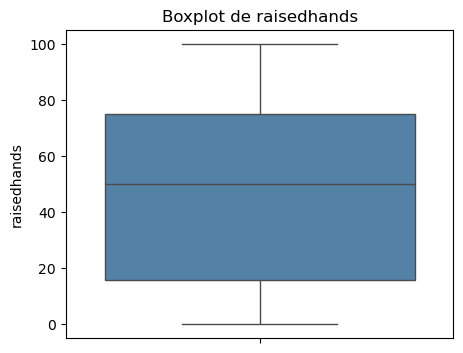

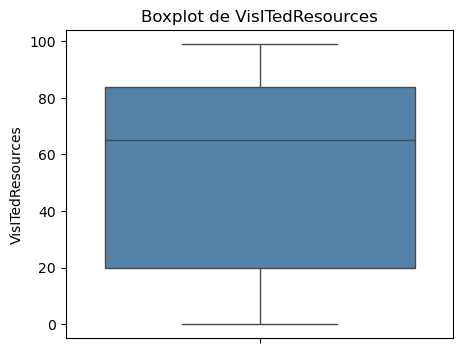

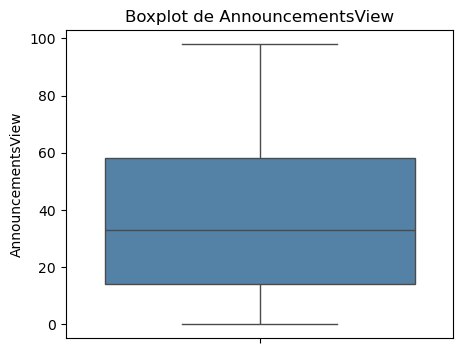

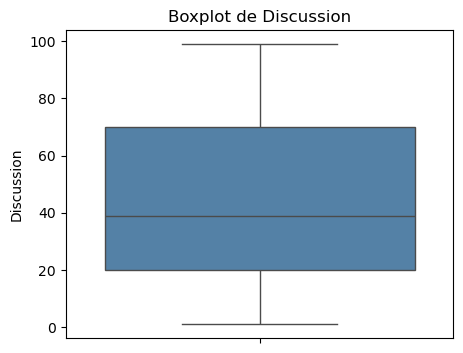

raisedhands: 0 atípicos | Límites: [-73.1, 163.9]
VisITedResources: 0 atípicos | Límites: [-76.0, 180.0]
AnnouncementsView: 0 atípicos | Límites: [-52.0, 124.0]
Discussion: 0 atípicos | Límites: [-55.0, 145.0]

El análisis no detectó ningún valor fuera de los límites calculados, ya que las 4 variables están naturalmente acotadas entre 0 y 100.


In [23]:
columnas_numericas = ['raisedhands', 'VisITedResources', 
                      'AnnouncementsView', 'Discussion']

# Boxplot general
for columna in columnas_numericas:
    plt.figure(figsize=(5,4))
    sns.boxplot(y=df[columna], color='steelblue')
    plt.title(f'Boxplot de {columna}')
    plt.ylabel(columna)
    plt.savefig(f'boxplot_{columna}.png', dpi=150, bbox_inches='tight')
    plt.show()

# IQR general
for columna in columnas_numericas:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    atipicos = df[(df[columna] < limite_inferior) | 
                  (df[columna] > limite_superior)]
    print(f"{columna}: {len(atipicos)} atípicos | "
          f"Límites: [{limite_inferior:.1f}, {limite_superior:.1f}]")

- El análisis no detectó ningún valor fuera de los límites calculados, ya que las 4 variables están entre 0 y 100.

### Control de Errores: ¿Qué pasa si entran datos con ruido?

Si el sistema registra datos imposibles fuera del rango lógico, como -50 o 120, la normalización Min-Max distorsionará los datos correctos del medio.

Para evitar esto, se aplican tres soluciones antes de normalizar:
1. **Truncar:** Forzar los números extremos para que regresen estrictamente al rango lógico real.
2. **Imputar:** Reemplazar los errores por la mediana de la columna.
3. **Eliminar:** Borrar las filas que representan un porcentaje mínimo dentro del total.

---

# 5. Limpieza de datos: normalización y codificación de categorías


### Normalización

Aplicamos normalización Min-Max a las 4 variables numéricas,
transformando sus valores al rango [0, 1].

**¿Por qué Min-Max y no Z-score?**

- **Min-Max:** adecuado cuando las variables tienen un rango conocido
  y acotado (0-100). Conserva la interpretación original:
  0 = mínima interacción, 1 = máxima interacción registrada.

- **Z-score:** adecuado cuando los datos siguen una distribución
  normal y existen valores extremos que distorsionen la escala.
  No aplica aquí ya que las variables no tienen outliers y su
  rango está naturalmente acotado.

In [11]:
#Normalización
df_clean = df.copy()

columnas = ["raisedhands", "VisITedResources", "AnnouncementsView", "Discussion"]

for col in columnas:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    df_clean[col] = (df_clean[col] - min_val) / (max_val - min_val)

df_clean[columnas].describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,0.467750,0.553514,0.386926,0.431463
std,0.307792,0.334141,0.271543,0.282018
min,0.000000,0.000000,0.000000,0.000000
25%,0.157500,0.202020,0.142857,0.193878
50%,0.500000,0.656566,0.336735,0.387755
75%,0.750000,0.848485,0.591837,0.704082
max,1.000000,1.000000,1.000000,1.000000


**Conclusión:** Las 4 variables numéricas (`raisedhands`, `VisITedResources`, `AnnouncementsView`, 
`Discussion`) fueron normalizadas a escala 0-1 mediante Min-Max.

Esto transforma todas las variables a una misma escala, dejando el valor más bajo en cero y el más alto en uno.

Al dejar todos los datos en el mismo rango, evitamos que las variables con números más grandes dominen el análisis.

---

### Codificación de variables categóricas

Convertimos las variables categóricas a formato numérico mediante
One-Hot Encoding (`pd.get_dummies`), usando `drop_first=True` para
evitar multicolinealidad: si una variable tiene 2 categorías, basta
con una columna binaria para representarla.

**¿Por qué One-Hot Encoding y no Label Encoding?**

- **One-Hot Encoding:** adecuado cuando las variables categóricas
  no tienen un orden natural. Crea columnas binarias independientes
  para cada categoría, evitando que el modelo interprete relaciones
  de magnitud entre ellas.

- **Label Encoding:** adecuado cuando las categorías tienen un orden.
  No aplica aquí ya que variables como `Topic` (IT, Math, English) o `NationalITy` no
  tienen ningún orden implícito entre sus categorías.

Por ejemplo, `StudentAbsenceDays` (Above-7/Under-7) se convierte
en una sola columna `StudentAbsenceDays_Under-7` con valores
True o False, en lugar de dos columnas redundantes.

El análisis exploratorio se realiza sobre `df` original para
mantener las categorías legibles (L/M/H, Under-7/Above-7).
`df_clean` codificado serviría como base para aplicar modelos
predictivos en un análisis futuro.

In [12]:
#Codificación de categorías
df_clean = pd.get_dummies(df_clean, drop_first=True)
df_clean.head()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_M,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,...,Topic_Quran,Topic_Science,Topic_Spanish,Semester_S,Relation_Mum,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Good,StudentAbsenceDays_Under-7,Class_L,Class_M
0,0.15,0.161616,0.020408,0.193878,True,False,False,False,True,False,...,False,False,False,False,False,True,True,True,False,True
1,0.20,0.202020,0.030612,0.244898,True,False,False,False,True,False,...,False,False,False,False,False,True,True,True,False,True
2,0.10,0.070707,0.000000,0.295918,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,0.30,0.252525,0.051020,0.346939,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,0.40,0.505051,0.122449,0.500000,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


- Se expandio el dataset de 17 a 62 columnas (`df_clean`), 
  sin generar nulos ni perder registros (480 filas se mantienen intactas).

### Validación post-limpieza

In [13]:
print("Shape original:", df.shape)
print("Shape df_clean:", df_clean.shape)
print("Nulos en df_clean:", df_clean.isnull().sum().sum())

Shape original: (480, 17)
Shape df_clean: (480, 62)
Nulos en df_clean: 0


Confirmamos que la limpieza no introdujo valores nulos y que las dimensiones del dataset 
codificado (`df_clean`) son coherentes: mismas 480 filas, pero más columnas (62) producto 
de la expansión de las variables categóricas en columnas binarias.

---

# 6. Análisis exploratorio

### Pregunta 1: ¿Cómo se relaciona la frecuencia con que un estudiante levanta la mano en clases con su nivel de rendimiento (L/M/H)?



Calculamos estadísticas descriptivas de `raisedhands` agrupadas por `Class`, y luego 
medimos la correlación entre ambas variables (mapeando L=0, M=1, H=2) para cuantificar 
qué tan fuerte es esa relación más allá de la simple comparación de promedios.

In [14]:
# Estadísticas
print(df.groupby('Class')['raisedhands'].describe().round(2))


       count   mean    std   min   25%   50%    75%    max
Class                                                     
H      142.0  70.29  22.54  10.0  62.0  75.0  85.75  100.0
L      127.0  16.89  17.21   0.0   6.0  10.0  20.50   80.0
M      211.0  48.94  26.89   0.0  24.5  50.0  72.00  100.0


In [15]:
df['Class_num'] = df['Class'].map({'L': 0, 'M': 1, 'H': 2})
corr_pearson = df['raisedhands'].corr(df['Class_num'], method='pearson')
print(f"Correlación de pearson: {corr_pearson:.3f}")

Correlación de pearson: 0.646


**RESPUESTA** 
- Los estudiantes con rendimiento H presentan un mayor promedio de participación en clases (raisedhands) que los estudiantes con rendimiento M y L, lo   que indica que una mayor participación esta asociada a un mayor rendimiento académico.

- La correlación entre raisedhands y el rendimiento es de 0.646,
  lo que indica una relación moderada-alta y positiva a mayor 
  participación en clases, mayor es el nivel académico obtenido.

### Visualización 1 (Matplotlib): Participación por nivel de rendimiento

Usamos un gráfico de barras para comparar visualmente el promedio de `raisedhands` entre 
los 3 niveles de rendimiento. Se eligió un gráfico de barras porque compara una variable 
numérica (promedio) entre categorías (L/M/H), que es justamente lo que queremos responder.

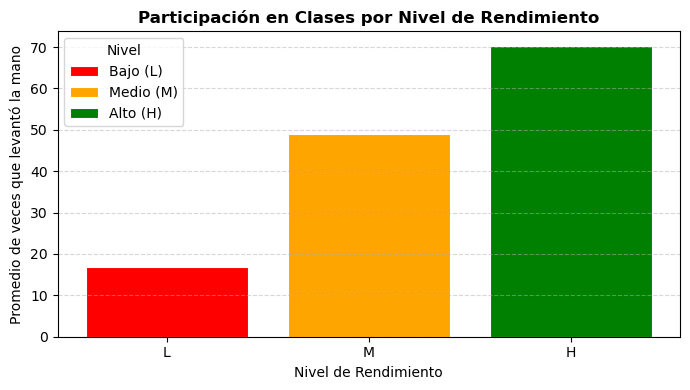

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

promedios = df.groupby('Class')['raisedhands'].mean().reindex(['L', 'M', 'H'])

ax.bar('L', promedios['L'], color='red', edgecolor='white', linewidth=0.8, label='Bajo (L)')
ax.bar('M', promedios['M'], color='orange', edgecolor='white', linewidth=0.8, label='Medio (M)')
ax.bar('H', promedios['H'], color='green', edgecolor='white', linewidth=0.8, label='Alto (H)')

ax.set_title('Participación en Clases por Nivel de Rendimiento', fontweight='bold')
ax.set_xlabel('Nivel de Rendimiento')
ax.set_ylabel('Promedio de veces que levantó la mano')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(title='Nivel')

plt.tight_layout()
plt.savefig('grafico_p1_raisedhands.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretación Gráfico 1

El gráfico de barras muestra el promedio de veces que 
los estudiantes levantaron la mano según su nivel de rendimiento.

**Nivel Bajo (L)**
- Promedio de 16.89 veces que levantó la mano
- El grupo menos participativo de los tres

**Nivel Medio (M)**
- Promedio de 48.94 veces que levantó la mano
- Participación intermedia entre L y H

**Nivel Alto (H)**
- Promedio de 70.29 veces que levantó la mano
- El grupo más participativo de los tres

**Conclusión:** Existe una relación directa entre la 
participación en clases y el rendimiento académico.
Los estudiantes de nivel Alto participan en promedio 
más que los de nivel Bajo (70.29 vs 16.89),
lo que sugiere que la participación en clases 
esta asociado a un mejor rendimiento académico.

---

### Pregunta 2: ¿Existe diferencia en el acceso a recursos entre estudiantes con nivel alto vs. bajo rendimiento?



Filtramos solo los grupos H y L (excluyendo M, ya que la pregunta es específicamente 
alto vs. bajo) y comparamos sus estadísticas de `VisITedResources` para cuantificar la 
brecha en uso de recursos educativos entre ambos extremos de rendimiento.

In [17]:
df.groupby("Class")["VisITedResources"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
H,142.0,78.746479,19.356468,4.0,71.75,84.0,90.75,99.0
L,127.0,18.322835,19.187000,0.0,6.00,11.0,23.00,90.0
M,211.0,60.635071,28.229746,2.0,38.50,72.0,82.50,99.0


In [18]:
h = df[df['Class']=='H']['VisITedResources'].mean()
l = df[df['Class']=='L']['VisITedResources'].mean()
print(f"Promedio nivel Alto: {h:.2f}")
print(f"Promedio nivel Bajo: {l:.2f}")
print(f"Diferencia: {h - l:.2f} recursos")
print(f"Nivel Alto visita {h/l:.1f} más recursos que nivel Bajo")

Promedio nivel Alto: 78.75
Promedio nivel Bajo: 18.32
Diferencia: 60.42 recursos
Nivel Alto visita 4.3 más recursos que nivel Bajo


**RESPUESTA** 
- Los estudiantes con rendimiento alto acceden, en promedio(78.75), una mayor cantidad de recursos educativos que los estudiantes con rendimiento bajo(18.32).

---

### Visualización 2 (Seaborn): Recursos visitados — Alto vs. Bajo

Usamos un boxplot porque permite ver no solo la diferencia de medianas entre ambos grupos, 
sino también su dispersión y posibles valores atípicos dentro de cada categoría, lo que 
un simple promedio no muestra.

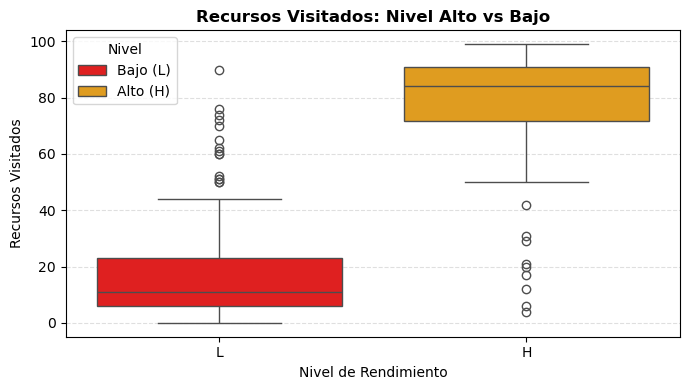

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))

df_hl = df[df['Class'].isin(['H', 'L'])]

sns.boxplot(
    data=df_hl, x='Class', y='VisITedResources',
    order=['L', 'H'], hue='Class',
    palette={'L': 'red', 'H': 'orange'},
    legend=True, ax=ax
)

ax.set_title('Recursos Visitados: Nivel Alto vs Bajo', fontweight='bold')
ax.set_xlabel('Nivel de Rendimiento')
ax.set_ylabel('Recursos Visitados')
ax.legend(title='Nivel', labels=['Bajo (L)', 'Alto (H)'])
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('grafico_p2.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretación Gráfico 2

El boxplot compara la distribución de recursos visitados 
entre estudiantes de nivel Alto (H) y Bajo (L).

**Nivel Bajo (L):**
- Mediana de 11 recursos visitados
- Caja concentrada entre 6 y 23
- Presenta valores atípicos hacia arriba indicando que estudiantes de 
  nivel Bajo visitaron más recursos de lo esperado

**Nivel Alto (H)**
- Mediana de 84 recursos visitados
- Caja concentrada entre 71 y 90
- Presenta valores atípicos hacia abajo indicando que estudiantes de 
  nivel Alto visitaron menos recursos de lo esperado

**Conclusión:** La diferencia entre ambos grupos es clara 
los estudiantes de nivel Alto acceden en promedio 
más recursos que los de nivel Bajo (78.75 vs 18.32).

---

### Pregunta 3: ¿Cómo influyen las ausencias (Under-7 vs. Above-7) en el rendimiento académico final?



Construimos una tabla de contingencia (`StudentAbsenceDays` vs. `Class`) en conteos y en 
porcentajes, para responder no solo cuántos estudiantes hay en cada combinación, sino qué 
proporción de cada grupo de asistencia cae en cada nivel de rendimiento.

In [20]:
# Porcentajes según asistencia y rendimiento académico
tabla = df.groupby('StudentAbsenceDays')['Class']\
          .value_counts(normalize=True).unstack().round(3)
print(tabla)
print("\n")

# Conteo de estudiantes por grupo de ausencia y nivel
tabla2 = df.groupby('StudentAbsenceDays')['Class']\
           .value_counts().unstack()
print(tabla2)

# Separar estudiantes según grupo de ausencia
above = df[df['StudentAbsenceDays']=='Above-7']  # más de 7 ausencias
under = df[df['StudentAbsenceDays']=='Under-7']  # menos de 7 ausencias

# Calculo para comparar ambos grupos
print(f"\nProcentaje de nivel Bajo con Above-7:  {(above['Class']=='L').mean()*100:.1f}%")
print(f"Porcentaje de nivel Alto con Above-7:  {(above['Class']=='H').mean()*100:.1f}%")
print(f"Porcentaje de nivel Bajo con Under-7:  {(under['Class']=='L').mean()*100:.1f}%")
print(f"Porcentaje de nivel Alto con Under-7:  {(under['Class']=='H').mean()*100:.1f}%")

Class                   H      L      M
StudentAbsenceDays                     
Above-7             0.021  0.607  0.372
Under-7             0.478  0.038  0.484


Class                 H    L    M
StudentAbsenceDays               
Above-7               4  116   71
Under-7             138   11  140

Procentaje de nivel Bajo con Above-7:  60.7%
Porcentaje de nivel Alto con Above-7:  2.1%
Porcentaje de nivel Bajo con Under-7:  3.8%
Porcentaje de nivel Alto con Under-7:  47.8%


**RESPUESTA** 
- Sobre 7 ausencias es menor la probabilidad de obtener nivel Alto (H) y es mayor la probabilidad de tener nivel Bajo (L). El nivel Medio (M) se   mantiene relativamente estable en ambos grupos.

### Visualización 3 (Seaborn): Rendimiento según días de ausencia

Usamos un gráfico de barras agrupadas (`countplot` con `hue`) porque permite comparar de 
forma directa la composición de niveles de rendimiento (L/M/H) dentro de cada categoría 
de asistencia (Above-7 / Under-7), mostrando visualmente el contraste que se describió en 
la tabla de porcentajes anterior.

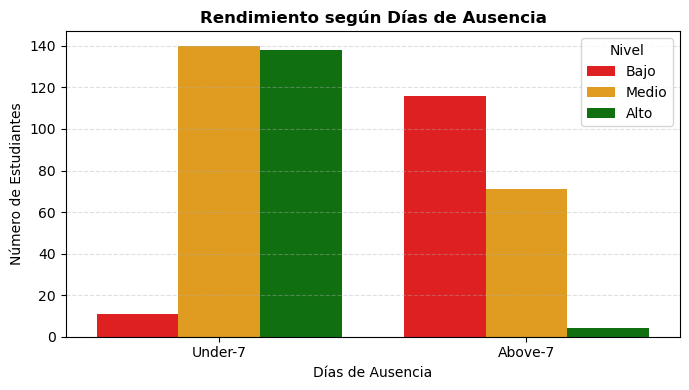

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.countplot(
    data=df, x='StudentAbsenceDays', hue='Class',
    hue_order=['L', 'M', 'H'],
    palette={'L': 'red', 'M': 'orange', 'H': 'green'},
    ax=ax
)

ax.set_title('Rendimiento según Días de Ausencia', fontweight='bold')
ax.set_xlabel('Días de Ausencia')
ax.set_ylabel('Número de Estudiantes')
ax.legend(title='Nivel', labels=['Bajo', 'Medio', 'Alto'])
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('grafico_p3.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretación Gráfico 3

El gráfico de barras agrupadas muestra la cantidad de 
estudiantes por nivel de rendimiento según sus días de ausencia.

**Estudiantes con más de 7 ausencias (Above-7)**
- Barra roja (L) predomina con 116 estudiantes
- Barra naranja (M) tiene 71 estudiantes
- Barra verde (H) tiene solo 4 estudiantes

**Estudiantes con menos de 7 ausencias (Under-7)**
- Barra verde (H) alta con 138 estudiantes
- Barra naranja (M) alta con 140 estudiantes
- Barra roja (L) tiene solo 11 estudiantes

**Conclusión:** El gráfico confirma visualmente que las 
ausencias tienen un impacto directo en el rendimiento.
Con más de 7 ausencias el nivel Bajo domina claramente,
mientras que con menos de 7 ausencias el nivel alto 
y Medio son los predominantes.

---

### Pregunta principal - ¿Cómo influyen factores socioeconómicos en el rendimiento académico de estudiantes?

Análisis de Causas Detrás del Rendimiento Académico

Al cruzar los datos con la literatura científica, podemos determinar las causas reales que provocan los comportamientos registrados en el LMS:

**1. Participación en clases y acceso a recursos**

- La Brecha Digital y Tecnológica: La falta de visitas a contenidos virtuales (VisITedResources) no se debe a desinterés del estudiante. La causa
  principal es la brecha digital de acceso en hogares vulnerables: conexiones inestables a internet, falta de computadores propios o la necesidad de
  compartir un único dispositivo familiar.

- Falta de Estímulo en el Entorno: La baja tasa de participación presencial (raisedhands) suele ser causada por una menor estimulación académica y
  falta de confianza en entornos socioculturales vulnerables, donde el estudiante no cuenta con un hábito de reforzamiento guiado en casa.

**2. Ausencias a clases**

- Barreras Logísticas y Sociales: El ausentismo crónico (Above-7) que empuja a los estudiantes al fracaso escolar no es una decisión voluntaria. Está   causado por factores de fuerza mayor externos al colegio: dificultades de transporte en zonas periféricas o rurales, problemas de salud familiar
  sin cobertura médica oportuna, o la necesidad de que los jóvenes asuman tareas de cuidado en el hogar.

**3. Participación del apoderado**

- Precarización del Tiempo Laboral: La causa de que un apoderado no responda las encuestas (ParentAnsweringSurvey = 'No') se debe a jornadas de
  trabajo  extenuantes, turnos rotativos, empleos informales o baja alfabetización digital para usar el portal.

**Rol de los padres**

La mamá es el mayor apoyo del estudiante. Cuando ella participa activamente en las encuestas del colegio, el porcentaje de estudiantes con bajo rendimiento es del 3.1%, y el 60% alcanza el nivel más alto. De hecho, aunque ella no participe, el 32.8% de los alumnos logra tener un desempeño alto.

Por otro lado, el comportamiento del papá funciona de otra forma. Si el papá es el apoderado y no participa en las encuestas, más de la mitad de los alumnos (el 55.9%) tiene un rendimiento bajo. Sin embargo, cuando el papá decide involucrarse y apoyar activamente, el rendimiento bajo cae a 17.1%.


**En resumen:** El bajo rendimiento académico (L) no es una falta de capacidad del alumno, sino de un conjunto de factores: las limitaciones económicas causan baja conectividad y ausentismo por factores externos, además de la participación de los apoderados en las encuestas del colegio.

In [22]:
# 1. Filtramos el dataset para el Padre
df_padres = df[df['Relation'].str.lower() == 'father'].copy()

print("==========================================================")
print(f"Total estudiantes con padre como apoderado: {len(df_padres)}")
print("==========================================================")
tabla_padres = pd.crosstab(
    df_padres['ParentAnsweringSurvey'], 
    df_padres['Class'], 
    normalize='index'
)[['L', 'M', 'H']] * 100
print(tabla_padres.round(1))

# 2. Filtramos el dataset para la Madre
df_madres = df[df['Relation'].str.lower() == 'mum'].copy()

print("\n==========================================================")
print(f"Total estudiantes con madre como apoderada: {len(df_madres)}")
print("==========================================================")
tabla_madres = pd.crosstab(
    df_madres['ParentAnsweringSurvey'], 
    df_madres['Class'], 
    normalize='index'
)[['L', 'M', 'H']] * 100
print(tabla_madres.round(1))

Total estudiantes con padre como apoderado: 283
Class                     L     M     H
ParentAnsweringSurvey                  
No                     55.9  39.9   4.2
Yes                    17.1  57.1  25.7

Total estudiantes con madre como apoderada: 197
Class                     L     M     H
ParentAnsweringSurvey                  
No                     28.4  38.8  32.8
Yes                     3.1  36.9  60.0


**Conclusión:** 

- Si el Padre responde las encuestas, el nivel de rendimiento bajo es de un 55.9% y el nivel alto es de apenas un 4.2%.

- Si el Padre si responde, el nivel bajo cae drásticamente a un 17.1% y el niel alto sube a un 25.7%.

- Si la Madre no responde las encuestas, el nivel bajo es de un 28.4% y el nivel alto se mantiene en un 32.8%.

- Si la Madre si responde, el nivel bajo cae a 3.1% y el nivel alto se dispara a 60.0%.

La participación de ambos padres es clave para el nivel acádemico de los estudiante, pero es el involucramiento de la madre el que dispara el nivel académico más alto.

---

## 7. Conexión entre Preguntas

- **Pregunta 1:** Mayor participación es igual a mayor rendimiento
- **Pregunta 2:** Mayor uso de recursos es igual a mayor rendimiento
- **Pregunta 3:** Menor ausentismo es igual a mayor rendimiento

Los tres factores miden distintos aspectos del compromiso
del estudiante con su proceso de aprendizaje.

---

## 8. Sugerencias de Análisis Futuro
Como futuros profesionales, entendemos que un análisis riguroso no solo responde preguntas, sino que abre el camino a futuras investigaciones con variables del mismo dataset:

**Análisis por género:**
Investigar si existe diferencia en los factores analizados 
entre estudiantes hombres y mujeres.

**Análisis por materia:**
Explorar si el rendimiento varía según la materia
que estudia el estudiante.

**Análisis por semestre:**
Comparar si los patrones de comportamiento cambian 
entre el primer y segundo semestre.

**Análisis por nivel educativo:**
Investigar si los factores tienen diferente impacto 
según el nivel educativo (lowerlevel, MiddleSchool, HighSchool).

---

## 9. Conclusiones

A partir de las preguntas respondidas, sintetizamos los hallazgos principales y el 
perfil de estudiante asociado a cada nivel de rendimiento.

- **Perfil de estudiante de nivel Alto:**
  participa activamente, aprovecha los recursos de la 
  plataforma, asiste regularmente a clases y cuenta principalmente a la madre como apoderada activa.

- **Perfil de estudiante de nivel Bajo:**
  baja participación, poco uso de recursos, alta ausencia, el rol de padre es escencial.

El rendimiento académico no depende de un solo factor 
sino de la combinación de participación, asistencia, uso de recursos y soporte familiar.

---